In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42

/opt/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/opt

In [2]:
h19 = sc.read_h5ad("/data/BG_ASC_revision_dataset_input2/HMBA_human_Astro_3subGroups.h5ad")
h19

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'donor_id', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac_non_nuclear_read_pairs', 'atac_number_of_peaks', 'atac_percent_duplicates', 'atac_q30_bases_in_barcode', 'atac_q30_bases_in_read_1', 'atac_q30_bases_in_read_2', 'atac_q30_bases_in_s

In [3]:
h19.obs["subGroup"] = pd.Categorical(h19.obs["subGroup"], categories=["GM STR", "GM exSTR", "WM"], ordered=True)

In [9]:
X = h19.raw.X

rows = np.random.choice(X.shape[0], 1000, replace=False)
cols = np.random.choice(X.shape[1], 1000, replace=False)

sub = X[rows][:, cols].toarray()
print(np.allclose(sub, np.round(sub)))
print(sub.max())

True
239.0


## 1.1 DEGs across clusters via scanpy

In [5]:
pd.crosstab(h19.obs['Cluster'], h19.obs['donor_id'])


donor_id,H18.30.001,H19.30.004,H20.30.001,H20.30.002,H21.30.004,H23.30.001,H24.30.001,H24.30.003,H24.30.004,H24.30.007
Cluster,,,,,,,,,,
Human-7,64,0,72,183,210,207,186,421,337,213
Human-14,1916,2,2804,3516,7588,5560,11132,10281,8592,7205
Human-28,48,1,4,5,73,258,217,116,679,91
Human-31,23,0,2504,9,242,46,38,35,424,29
Human-145,35,12,164,158,186,85,313,512,135,183
Human-146,13,0,116,2,12,15,3,3,3,5
Human-149,37,15,2034,22,261,56,25,30,129,40
Human-150,43,5,983,3,97,23,16,22,145,22
Human-152,16,20,955,38,12,16,93,82,75,15


In [6]:
def downsample_adata(
    adata,
    group_key,
    donor_key,
    max_cells=200,
    min_cells=10,
    random_state=123,
    verbose=True
):
    
    rng = np.random.default_rng(random_state)
    keep_indices = []
    
    dropped = 0
    kept = 0

    for donor in sorted(adata.obs[donor_key].unique()):
        adata_donor = adata[adata.obs[donor_key] == donor]
        
        for grp in sorted(adata_donor.obs[group_key].unique()):
            idx = adata_donor.obs[group_key] == grp
            cells = adata_donor.obs[idx].index.values
            
            # filter very low-coverage
            if len(cells) < min_cells:
                dropped += 1
                continue
            
            # downsample
            if len(cells) > max_cells:
                sampled = rng.choice(cells, max_cells, replace=False)
            else:
                sampled = cells
            
            keep_indices.extend(sampled)
            kept += 1

    if verbose:
        print(f"[Downsample] kept groups: {kept}, dropped groups (<{min_cells} cells): {dropped}")
        print(f"[Downsample] total cells kept: {len(keep_indices)}")

    return adata[keep_indices].copy()


In [7]:
h19_cluster_ds = downsample_adata(
    h19,
    group_key="Cluster",
    donor_key="donor_id",
    max_cells=200,
    min_cells=10
)


[Downsample] kept groups: 152, dropped groups (<10 cells): 30
[Downsample] total cells kept: 19142


In [10]:
pd.crosstab(h19_cluster_ds.obs['Cluster'], h19_cluster_ds.obs['donor_id'])


donor_id,H18.30.001,H19.30.004,H20.30.001,H20.30.002,H21.30.004,H23.30.001,H24.30.001,H24.30.003,H24.30.004,H24.30.007
Cluster,,,,,,,,,,
Human-7,64,0,72,183,200,200,186,200,200,200
Human-14,200,0,200,200,200,200,200,200,200,200
Human-28,48,0,0,0,73,200,200,116,200,91
Human-31,23,0,200,0,200,46,38,35,200,29
Human-145,35,12,164,158,186,85,200,200,135,183
Human-146,13,0,116,0,12,15,0,0,0,0
Human-149,37,15,200,22,200,56,25,30,129,40
Human-150,43,0,200,0,97,23,16,22,145,22
Human-152,16,20,200,38,12,16,93,82,75,15


In [11]:
results = []

for sg in h19_cluster_ds.obs["subGroup"].unique():

    print(f"\nProcessing subgroup: {sg}")

    ad_sub = h19_cluster_ds[h19_cluster_ds.obs["subGroup"] == sg].copy()

    # run DE
    sc.tl.rank_genes_groups(
        ad_sub,
        groupby="Cluster",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        pts=True,
        use_raw=False,
        reference="rest",
        key_added="cluster"
    )

    # extract
    groups = ad_sub.uns["cluster"]["names"].dtype.names

    df = pd.concat([
        sc.get.rank_genes_groups_df(ad_sub, group=grp, key="cluster")
        .assign(cluster=grp, subgroup=sg)
        for grp in groups
    ])

    results.append(df)

# merge all
df_all_clusters = pd.concat(results, ignore_index=True)


# filtering
df_all_clusters_filtered = df_all_clusters[
    (df_all_clusters['pvals_adj'] < 0.05) &
    (df_all_clusters['logfoldchanges'] > 0.5) &
    (df_all_clusters['pct_nz_group'] > 0.1)
].copy()


df_all_clusters_filtered.to_csv("/scratch/Cluster_DEGs_within_subgroup_scanpy-wilcoxon.csv", index=False)



Processing subgroup: GM STR

Processing subgroup: GM exSTR

Processing subgroup: WM


In [12]:
df_all_clusters.to_csv("/scratch/Cluster_DEGs_within_subgroup_scanpy-wilcoxon_all.csv", index=False)


## 1.2  DEGs across Clusters (within subgroup) via pseudobulk DEseq2

In [13]:
from scipy.sparse import issparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

In [62]:
def _get_counts_matrix(adata, layer_key=None):
   
    """Return dense integer count matrix (cells x genes) and gene names."""
    
    if layer_key is not None:
        X = adata.layers[layer_key]
        genes = adata.var_names
    elif adata.raw is not None:
        X = adata.raw.X
        genes = adata.raw.var_names
    else:
        X = adata.X
        genes = adata.var_names

    if issparse(X):
        X = X.toarray()
    X = np.asarray(X)

    if (X < 0).any():
        raise ValueError("Counts contain negative values. DESeq2 expects non-negative counts.")

    # Cast to int safely
    if not np.issubdtype(X.dtype, np.integer):
        Xr = np.rint(X)
        if not np.allclose(X, Xr, atol=1e-6):
            raise ValueError("Counts are non-integer-like. Provide raw counts in .raw or a counts layer.")
        X = Xr.astype(np.int64)
    else:
        X = X.astype(np.int64)

    return X, genes


def run_within_subgroup_cluster_pseudobulk_deseq2(
    adata,
    subgroup_name,
    subgroup_key="subGroup",
    cluster_key="Cluster",
    donor_key="donor_id",
    layer_key=None,          # e.g. "UMI_counts"; if None -> use adata.raw.X if present else adata.X
    n_cells=2000,             # per donor per side (cluster/rest) cap
    min_cells_side=10,       # donor must have >= this many cells in cluster AND in rest
    min_donors=2,            # cluster must have >= this many donors passing min_cells_side
    min_gene_counts=5,       # filter genes by total counts across all pseudo-bulk samples for this cluster
    padj_thr=0.05,
    lfc_thr=0.5,
    random_state=123,
    n_cpus=2,
    return_all_genes=False,  # if False: keep only significant genes
):
    
    rng = np.random.default_rng(random_state)
    inference = DefaultInference(n_cpus=n_cpus)

    # ---- subset subgroup ----
    obs = adata.obs
    if subgroup_key not in obs.columns:
        raise KeyError(f"{subgroup_key} not in adata.obs")
    if cluster_key not in obs.columns:
        raise KeyError(f"{cluster_key} not in adata.obs")
    if donor_key not in obs.columns:
        raise KeyError(f"{donor_key} not in adata.obs")

    mask = obs[subgroup_key].astype(str) == str(subgroup_name)
    ad_sub = adata[mask].copy()
    if ad_sub.n_obs == 0:
        raise ValueError(f"No cells found for subgroup '{subgroup_name}'")

    # ---- counts ----
    X, genes = _get_counts_matrix(ad_sub, layer_key=layer_key)
    counts_df = pd.DataFrame(X, index=ad_sub.obs_names, columns=genes)

    obs_sub = ad_sub.obs.copy()
    obs_sub[donor_key] = obs_sub[donor_key].astype(str)
    obs_sub[cluster_key] = obs_sub[cluster_key].astype(str)

    donors = sorted(obs_sub[donor_key].unique())
    clusters = sorted(obs_sub[cluster_key].unique())

    all_res = []
    summary_rows = []

    for cl in clusters:
        pb_rows = []
        meta_rows = []

        used_donors = []

        for d in donors:
            donor_cells = obs_sub.index[obs_sub[donor_key] == d]

            # cells in this donor for target cluster / rest (within subgroup)
            cells_cluster = obs_sub.index[(obs_sub[donor_key] == d) & (obs_sub[cluster_key] == cl)]
            cells_rest    = obs_sub.index[(obs_sub[donor_key] == d) & (obs_sub[cluster_key] != cl)]

            if len(cells_cluster) < min_cells_side or len(cells_rest) < min_cells_side:
                continue

            # downsample each side to n_cells
            if len(cells_cluster) > n_cells:
                cells_cluster = rng.choice(cells_cluster, n_cells, replace=False)
            if len(cells_rest) > n_cells:
                cells_rest = rng.choice(cells_rest, n_cells, replace=False)

            # sum counts to pseudo-bulk
            cl_sum = counts_df.loc[cells_cluster].sum(axis=0)
            rs_sum = counts_df.loc[cells_rest].sum(axis=0)

            pb_rows.append(cl_sum)
            meta_rows.append({donor_key: d, "condition": "cluster"})

            pb_rows.append(rs_sum)
            meta_rows.append({donor_key: d, "condition": "rest"})

            used_donors.append(d)

        n_donors_used = len(set(used_donors))
        if n_donors_used < min_donors:
            summary_rows.append({
                "subgroup": subgroup_name,
                "cluster": cl,
                "n_donors_used": n_donors_used,
                "n_sig_genes": 0,
                "status": "skipped_low_donors"
            })
            continue

        # build pseudo-bulk matrices
        counts_pb = pd.DataFrame(pb_rows)
        meta_pb = pd.DataFrame(meta_rows)
        counts_pb.index = [f"s{i}" for i in range(len(counts_pb))]
        meta_pb.index = counts_pb.index

        # gene filter
        gene_mask = counts_pb.sum(axis=0) >= min_gene_counts
        counts_pb = counts_pb.loc[:, gene_mask].astype(int)

        # DESeq2
        try:
            dds = DeseqDataSet(
                counts=counts_pb,
                metadata=meta_pb,
                design=f"~ {donor_key} + condition",
                inference=inference,
                refit_cooks=True,
            )
            dds.deseq2()

            stats = DeseqStats(
                dds,
                contrast=["condition", "cluster", "rest"],
                inference=inference,
            )
            stats.summary()   

            if hasattr(stats, "results_df"):
                res = stats.results_df.copy()
            elif hasattr(stats, "results"):
                res = stats.results.copy()
            else:
                raise ValueError("No DESeq2 results found after summary()")

        except Exception as e:
            print(f"\n❌ ERROR in subgroup={subgroup_name}, cluster={cl}")
            print(type(e).__name__, ":", e)
    
            summary_rows.append({
                "subgroup": subgroup_name,
                "cluster": cl,
                "n_donors_used": n_donors_used,
                "n_sig_genes": 0,
                "status": f"error_{type(e).__name__}"
            })
            continue

        # format results
        res = res.copy()
        res["gene"] = res.index
        res["subgroup"] = subgroup_name
        res["cluster"] = cl
        res["n_donors_used"] = n_donors_used

        # filter significant (optional)
        if return_all_genes:
            res_out = res.reset_index(drop=True)
        else:
            res_out = res[
                (res["padj"].notna()) &
                (res["padj"] < padj_thr) &
                (res["log2FoldChange"] > lfc_thr) ## res["log2FoldChange"].abs() > lfc_thr
            ].reset_index(drop=True)

        all_res.append(res_out)

        summary_rows.append({
            "subgroup": subgroup_name,
            "cluster": cl,
            "n_donors_used": n_donors_used,
            "n_sig_genes": int(res_out.shape[0]) if not return_all_genes else int(
                ((res["padj"].notna()) & (res["padj"] < padj_thr) & (res["log2FoldChange"] > lfc_thr)).sum()
            ),
            "status": "ok"
        })

    df_all = pd.concat(all_res, ignore_index=True) if len(all_res) else pd.DataFrame()
    df_summary = pd.DataFrame(summary_rows)

    return df_all, df_summary


In [63]:
subgroups = ["GM STR", "GM exSTR", "WM"]

all_deg = []
all_summary = []

for sg in subgroups:
    print(f"Running DESeq2 for subgroup: {sg}")
    
    df_deg, df_sum = run_within_subgroup_cluster_pseudobulk_deseq2(
        adata=h19_cluster_ds,
        subgroup_name=sg,
        subgroup_key="subGroup",
        cluster_key="Cluster",
        donor_key="donor_id",
        layer_key=None,     
        n_cells=1500,
        min_cells_side=10,
        min_donors=2,
        min_gene_counts=5,
        padj_thr=0.05,
        lfc_thr=0.5,
        random_state=123,
        n_cpus=4,
        return_all_genes=False,
    )
    
    if df_deg is not None and len(df_deg) > 0:
        all_deg.append(df_deg)
    
    if df_sum is not None and len(df_sum) > 0:
        all_summary.append(df_sum)

# merge
df_all_deg = pd.concat(all_deg, ignore_index=True) if all_deg else pd.DataFrame()
df_all_summary = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()



df_all_deg.to_csv("/scratch/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2.csv", index=False)
df_all_summary.to_csv("/scratch/Cluster_DEGs_DESeq2_subgroups_summary.csv", index=False)

print("Saved CSV files")

Running DESeq2 for subgroup: GM STR
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 3.22 seconds.

Fitting dispersion trend curve...
... done in 0.43 seconds.

Fitting MAP dispersions...
... done in 5.43 seconds.

Fitting LFCs...
... done in 4.80 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.20 seconds.



Log2 fold change & Wald test p-value: condition cluster vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1    1.540148        0.277827  0.804175  0.345481  0.729733       NaN
AL627309.5    5.181745       -0.191329  0.440371 -0.434472  0.663946  0.949879
LINC01409    29.944401        0.181843  0.203651  0.892915  0.371903  0.844212
LINC01128    19.969773       -0.188198  0.222688 -0.845118  0.398045  0.855046
LINC00115     3.049698       -0.042325  0.573215 -0.073839  0.941139  0.992286
...                ...             ...       ...       ...       ...       ...
AL592183.1  115.507957        0.014719  0.142408  0.103356  0.917680  0.991606
AC240274.1    6.348762       -0.080498  0.400330 -0.201079  0.840636  0.980011
AC004556.3    0.505031        0.243149  1.777195  0.136816  0.891176       NaN
AC007325.4    3.039398        0.235332  0.625415  0.376282  0.706707  0.957159
AC007325.2   24.049600        0.470673  0.236254  1.992230  0.04634

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


...

Log2 fold change & Wald test p-value: condition cluster vs rest
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   1.011045        0.789271  1.059971  0.744616  0.456504       NaN
AL627309.5   1.810507       -1.362787  1.245928 -1.093792  0.274046       NaN
AL669831.2   0.158072        1.614701  1.834362  0.880252  0.378723       NaN
LINC01409   18.099414        0.622606  0.474792  1.311325  0.189748  0.897334
LINC01128   10.475451       -0.308893  0.600023 -0.514802  0.606692  0.995300
...               ...             ...       ...       ...       ...       ...
AL592183.1  46.453094        0.141236  0.395502  0.357105  0.721013  0.995841
AC240274.1   3.781529       -0.045247  0.817149 -0.055372  0.955842  0.998856
AC004556.3   0.364927        1.346506  1.358700  0.991026  0.321673       NaN
AC007325.4   2.931064        1.066823  0.759460  1.404712  0.160107  0.876258
AC007325.2   7.191827        0.033343  0.636746  0.052365  0.958238  0.998856


Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 4.11 seconds.

Fitting dispersion trend curve...
/opt/conda/lib/python3.10/site-packages/pydeseq2/dds.py:807: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 6.82 seconds.

Fitting LFCs...
... done in 5.08 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.35 seconds.



Log2 fold change & Wald test p-value: condition cluster vs rest
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   2.581711        0.413937  0.471186  0.878499  0.379673  0.780862
AL627309.5   5.621712        0.068721  0.325960  0.210828  0.833022  0.965809
AL669831.2   0.306692        0.225542  1.104507  0.204202  0.838196       NaN
LINC01409   25.152890       -0.184011  0.170338 -1.080264  0.280025  0.699575
FAM87B       0.282674        0.587037  1.001623  0.586086  0.557818       NaN
...               ...             ...       ...       ...       ...       ...
AC240274.1   9.067964        0.275469  0.250312  1.100499  0.271115  0.691037
AC004556.3   0.336976        0.469031  1.059512  0.442686  0.657993       NaN
AC007325.1   0.418730        1.493088  0.983211  1.518583  0.128867       NaN
AC007325.4   4.566069       -0.257764  0.331569 -0.777407  0.436919  0.815596
AC007325.2  15.573019       -0.142431  0.203243 -0.700789  0.483434  0.840929


## 1.3 scanpy-wilcoxon vs. pseudobulk-DESeq2

In [4]:
df_all_clusters_filtered = pd.read_csv("/scratch/Cluster_DEGs_within_subgroup_scanpy-wilcoxon.csv")
df_all_deg = pd.read_csv("/scratch/Cluster_DEGs_within_subgroup_pseudobulk-DESeq2.csv")

In [5]:
def compare_candidate_markers_support(
    df_scanpy_filtered,
    df_deseq2,                    
    cluster_col_scanpy="cluster",
    gene_col_scanpy="names",
    cluster_col_deseq="cluster",
    gene_col_deseq="gene",
    padj_col="padj",
    lfc_col="log2FoldChange",
    padj_thr=0.05,
    lfc_thr=0.5,
    require_same_direction=True,  
):
    out_rows = []
    overlap_lists = []

    clusters = sorted(set(df_scanpy_filtered[cluster_col_scanpy].astype(str).unique())
                      & set(df_deseq2[cluster_col_deseq].astype(str).unique()))

    for cl in clusters:
        sc = df_scanpy_filtered[df_scanpy_filtered[cluster_col_scanpy].astype(str) == str(cl)].copy()
        de = df_deseq2[df_deseq2[cluster_col_deseq].astype(str) == str(cl)].copy()

        sc_genes = sc[gene_col_scanpy].astype(str).unique().tolist()
        sc_set = set(sc_genes)

        # DESeq2
        de_sig = de[(de[padj_col].notna()) & (de[padj_col] < padj_thr)].copy()

        if require_same_direction:
            de_sig = de_sig[de_sig[lfc_col] > lfc_thr]
        else:
            de_sig = de_sig[de_sig[lfc_col].abs() > lfc_thr]

        de_set = set(de_sig[gene_col_deseq].astype(str).tolist())

        overlap = sorted(sc_set & de_set)

        out_rows.append({
            "cluster": cl,
            "n_scanpy_candidates": len(sc_set),
            "n_deseq2_supported": len(overlap),
            "support_fraction": (len(overlap) / len(sc_set)) if len(sc_set) else np.nan
        })

        overlap_lists.append(pd.DataFrame({
            "cluster": cl,
            "gene": overlap
        }))

    df_support = pd.DataFrame(out_rows).sort_values("support_fraction", ascending=False)
    df_overlap_genes = pd.concat(overlap_lists, ignore_index=True) if overlap_lists else pd.DataFrame()

    return df_support, df_overlap_genes

In [6]:
print(df_all_clusters_filtered.head())
print(df_all_deg.head())

    names     scores  logfoldchanges          pvals      pvals_adj  \
0   PDE4D  36.881264        3.617629  9.228806e-298  3.377835e-293   
1   DCHS2  34.088455        5.554002  1.093734e-254  1.334392e-250   
2   FSTL5  28.766426        2.585087  5.644271e-182  2.582324e-178   
3  GABRB1  27.972440        1.094232  3.517055e-172  1.287277e-168   
4   TENM3  27.224790        3.068331  3.305177e-163  1.008106e-159   

   pct_nz_group  pct_nz_reference  cluster subgroup  
0      0.987375          0.743291  Human-7   GM STR  
1      0.798671          0.241151  Human-7   GM STR  
2      0.965449          0.775574  Human-7   GM STR  
3      0.998671          0.976274  Human-7   GM STR  
4      0.926246          0.652664  Human-7   GM STR  
    baseMean  log2FoldChange     lfcSE      stat        pvalue      padj  \
0  63.226836        0.592689  0.139451  4.250156  2.136221e-05  0.001096   
1  98.989663        0.547511  0.130475  4.196301  2.713100e-05  0.001341   
2  21.646613        0.89329

In [7]:
df_support, df_overlap_genes = compare_candidate_markers_support(
    df_scanpy_filtered=df_all_clusters_filtered, #scanpy-wilcoxon
    df_deseq2=df_all_deg,   #  DESeq2
    padj_thr=0.05,
    lfc_thr=0.5,
    require_same_direction=True
)

#df_support.to_csv("/scratch/candidate_marker_support_by_cluster.csv", index=False)
#df_overlap_genes.to_csv("/scratch/candidate_marker_supported_genes.csv", index=False)

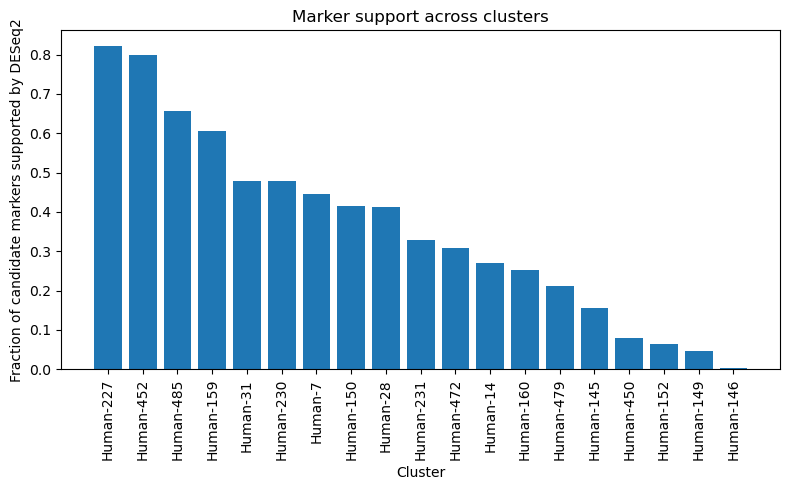

In [8]:
import matplotlib.pyplot as plt

df_plot = df_support.sort_values("support_fraction", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(df_plot["cluster"], df_plot["support_fraction"])
plt.xticks(rotation=90)
plt.ylabel("Fraction of candidate markers supported by DESeq2")
plt.xlabel("Cluster")
plt.title("Marker support across clusters")
plt.tight_layout()
plt.show()

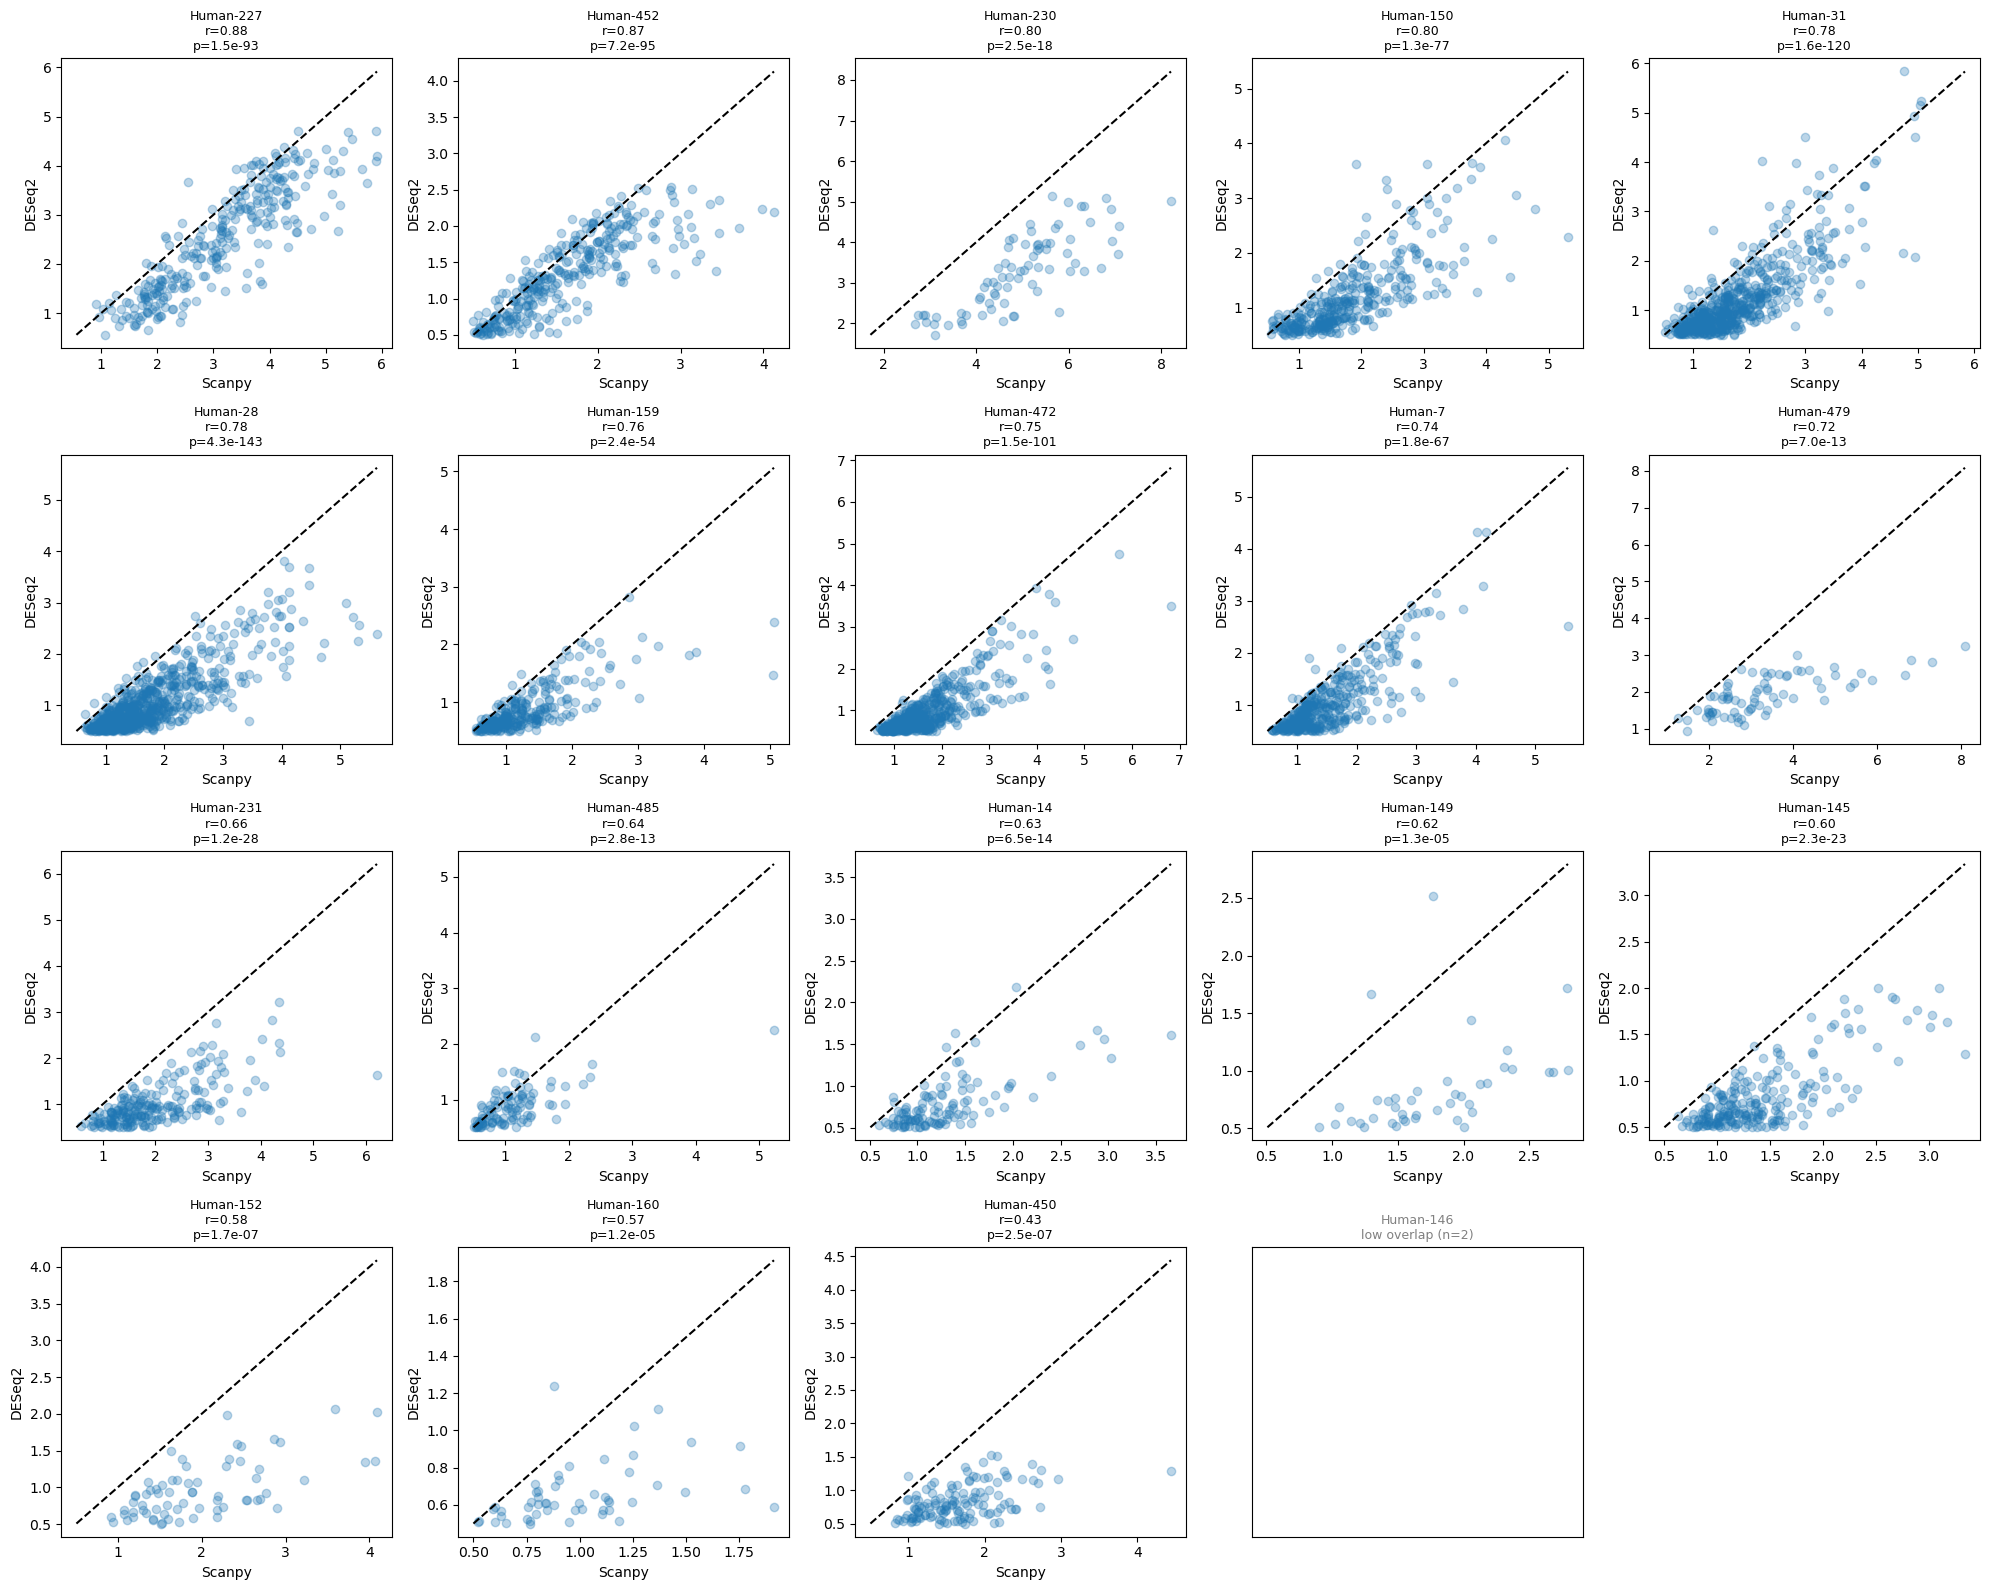

In [9]:
import matplotlib.pyplot as plt
import math
from scipy.stats import spearmanr

# -------- Step 1:  Spearman and order --------
cluster_stats = []

all_clusters = sorted(df_all_clusters_filtered["cluster"].unique())

for cl in all_clusters:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        continue

    df_scanpy_tmp = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq_tmp = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy_tmp, df_deseq_tmp, on="gene")

    if df_merge.shape[0] < 10:
        continue

    r, _ = spearmanr(df_merge["logFC_scanpy"], df_merge["logFC_deseq"])

    cluster_stats.append({
        "cluster": cl,
        "n_overlap": df_merge.shape[0],
        "spearman_r": r
    })

df_cluster_stats = pd.DataFrame(cluster_stats)

# order
df_cluster_stats = df_cluster_stats.sort_values("spearman_r", ascending=False)

clusters_sorted = df_cluster_stats["cluster"].tolist()

missing_clusters = [c for c in all_clusters if c not in clusters_sorted]
clusters_sorted += missing_clusters


# -------- Step2: plot --------
cols = 5
rows = math.ceil(len(clusters_sorted) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4)) 
axes = axes.flatten()

for i, cl in enumerate(clusters_sorted):
    ax = axes[i]

    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        ax.text(0.5, 0.5, f"{cl}\n(no data)",
                ha='center', va='center', fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    df_scanpy = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy, df_deseq, on="gene")

    # -------- low overlap --------
    if df_merge.shape[0] < 10:
        ax.set_title(f"{cl}\nlow overlap (n={df_merge.shape[0]})",
                     fontsize=9, color="gray")

        ax.text(0.5, 0.5, "",
                ha='center', va='center',
                fontsize=9, color="gray")

        ax.set_xticks([])
        ax.set_yticks([])
        continue

    x = df_merge["logFC_scanpy"]
    y = df_merge["logFC_deseq"]

    ax.scatter(x, y, alpha=0.3)

    r, p = spearmanr(x, y)

    # format p-value
    if p < 1e-300:
        p_str = "<1e-300"
    else:
        p_str = f"{p:.1e}"

    # diagonal
    lims = [
        min(x.min(), y.min()),
        max(x.max(), y.max())
    ]
    ax.plot(lims, lims, 'k--')

    ax.set_title(f"{cl}\nr={r:.2f}\np={p_str}", fontsize=9)

    ax.set_xlabel("Scanpy")
    ax.set_ylabel("DESeq2")

    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "/scratch/spearman_cluster_scanpy_vs_deseq2.pdf",
    bbox_inches="tight",
    dpi=400
)
plt.show()

In [28]:
df_cluster_stats

,cluster,n_overlap,spearman_r
0,Human-14,114,0.629283
1,Human-145,223,0.601791
2,Human-146,2,NaN
3,Human-149,41,0.624739
4,Human-150,341,0.801264
5,Human-152,68,0.584189
6,Human-159,278,0.763516
7,Human-160,52,0.567062
8,Human-227,284,0.880768
9,Human-230,76,0.803281


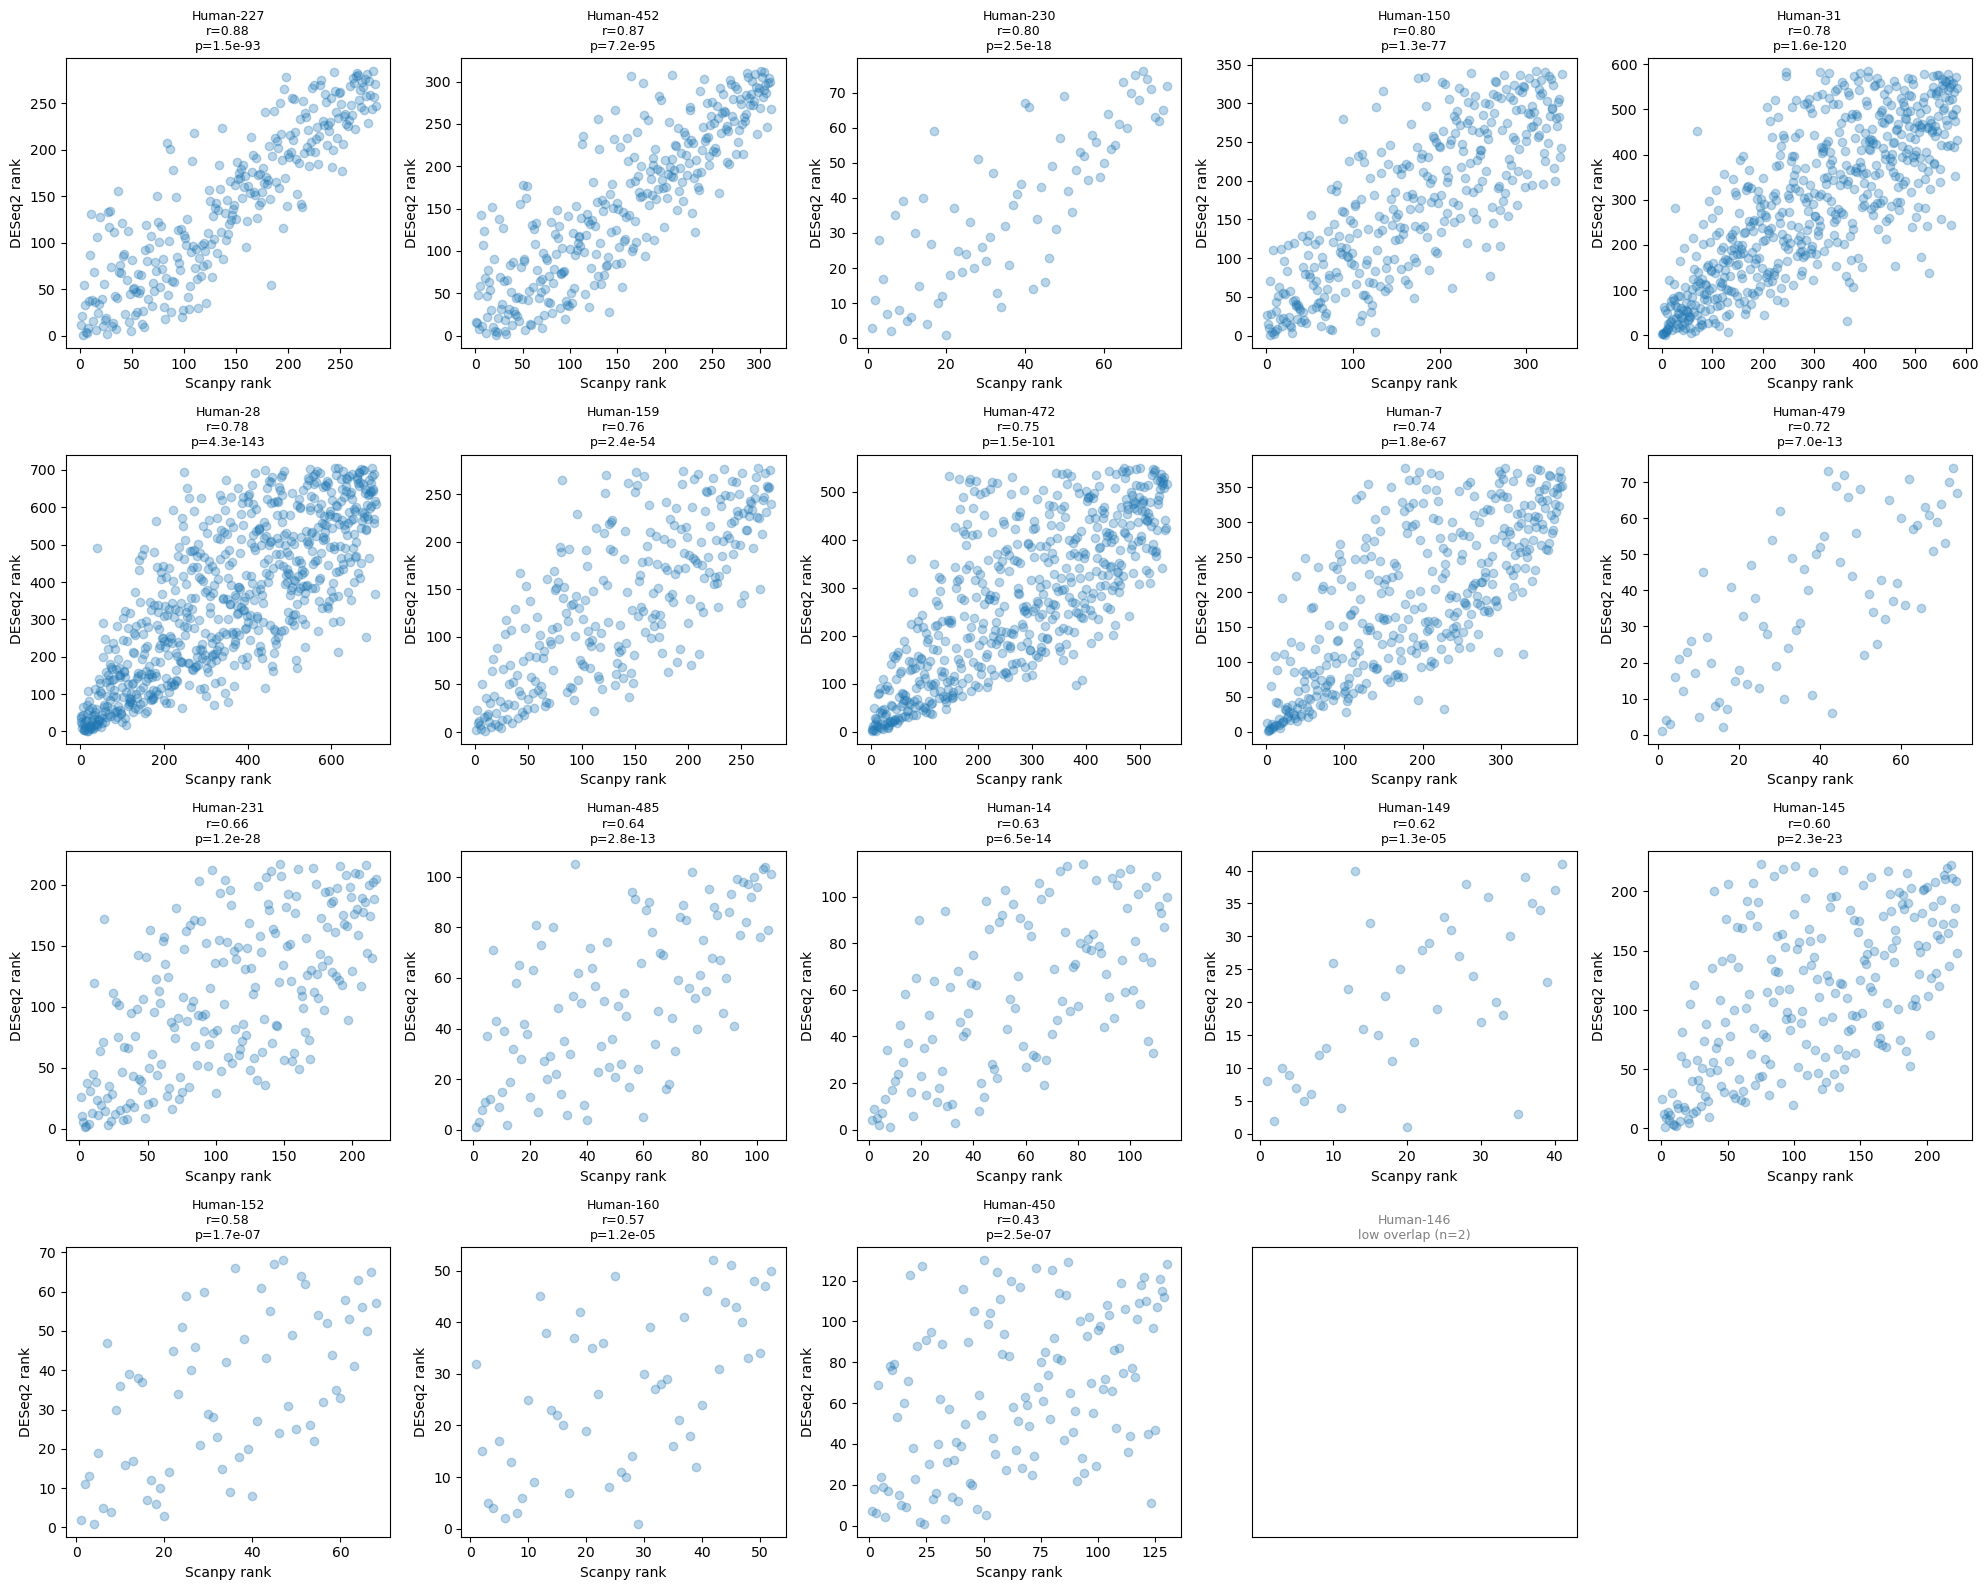

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import spearmanr

# -------- Step 1: compute rank-based correlation --------
cluster_stats = []

all_clusters = sorted(df_all_clusters_filtered["cluster"].unique())

for cl in all_clusters:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        continue

    df_scanpy_tmp = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq_tmp = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy_tmp, df_deseq_tmp, on="gene")

    if df_merge.shape[0] < 10:
        continue

    # -------- rank transform --------
    df_merge["rank_scanpy"] = df_merge["logFC_scanpy"].rank(ascending=False)
    df_merge["rank_deseq"] = df_merge["logFC_deseq"].rank(ascending=False)

    r, p = spearmanr(df_merge["rank_scanpy"], df_merge["rank_deseq"])

    cluster_stats.append({
        "cluster": cl,
        "n_overlap": df_merge.shape[0],
        "spearman_r": r,
        "pval": p
    })

df_cluster_stats = pd.DataFrame(cluster_stats)

# -------- order clusters --------
df_cluster_stats = df_cluster_stats.sort_values("spearman_r", ascending=False)
clusters_sorted = df_cluster_stats["cluster"].tolist()

missing_clusters = [c for c in all_clusters if c not in clusters_sorted]
clusters_sorted += missing_clusters

# -------- Step 2: plotting --------
cols = 5
rows = math.ceil(len(clusters_sorted) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for i, cl in enumerate(clusters_sorted):
    ax = axes[i]

    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        ax.text(0.5, 0.5, f"{cl}\n(no data)",
                ha='center', va='center', fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    df_scanpy = df_scanpy.rename(columns={
        "names": "gene",
        "logfoldchanges": "logFC_scanpy"
    })
    df_deseq = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    })

    df_merge = pd.merge(df_scanpy, df_deseq, on="gene")

    if df_merge.shape[0] < 10:
        ax.set_title(f"{cl}\nlow overlap (n={df_merge.shape[0]})",
                     fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    # -------- rank transform --------
    df_merge["rank_scanpy"] = df_merge["logFC_scanpy"].rank(ascending=False)
    df_merge["rank_deseq"] = df_merge["logFC_deseq"].rank(ascending=False)

    x = df_merge["rank_scanpy"]
    y = df_merge["rank_deseq"]

    ax.scatter(x, y, alpha=0.3)

    r, p = spearmanr(x, y)

    # p-value format
    if p < 1e-300:
        p_str = "<1e-300"
    else:
        p_str = f"{p:.1e}"

    ax.set_title(f"{cl}\nr={r:.2f}\np={p_str}", fontsize=9)

    ax.set_xlabel("Scanpy rank")
    ax.set_ylabel("DESeq2 rank")

# remove empty panels
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "/scratch/rank_spearman_cluster_scanpy_vs_deseq2.pdf",
    bbox_inches="tight",
    dpi=400
)

plt.show()

In [73]:
# ================================
# Additional: gene-level overlap table
# ================================

overlap_rows = []

for cl in clusters_sorted:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    if df_deseq.empty or df_scanpy.empty:
        continue

    # --- rename for merge ---
    df_scanpy_tmp = df_scanpy.rename(columns={
        "names": "gene"
    }).copy()

    df_deseq_tmp = df_deseq.rename(columns={
        "log2FoldChange": "logFC_deseq"
    }).copy()

    # --- merge ---
    df_merge = pd.merge(df_scanpy_tmp, df_deseq_tmp, on="gene")
    df_merge["cluster"] = cl

    if df_merge.empty:
        continue

    # --- add prefixes ---
    scanpy_cols = [c for c in df_scanpy_tmp.columns if c not in ["gene", "cluster"]]
    deseq_cols = [c for c in df_deseq_tmp.columns if c not in ["gene", "cluster"]]

    df_merge_prefixed = df_merge.copy()

    for c in scanpy_cols:
        if c in df_merge_prefixed.columns:
            df_merge_prefixed.rename(columns={c: f"scanpy_wilcoxon_{c}"}, inplace=True)

    for c in deseq_cols:
        if c in df_merge_prefixed.columns:
            df_merge_prefixed.rename(columns={c: f"pseudobulk_DESeq2_{c}"}, inplace=True)

    # --- keep cluster + gene first ---
    cols = ["cluster", "gene"] + [c for c in df_merge_prefixed.columns if c not in ["cluster", "gene"]]
    df_merge_prefixed = df_merge_prefixed[cols]

    overlap_rows.append(df_merge_prefixed)


# concat all clusters
df_overlap_full = pd.concat(overlap_rows, ignore_index=True) if overlap_rows else pd.DataFrame()

# save
df_overlap_full.to_csv("/scratch/Cluster_level_DEGs_overlap-wilcoxon-DEseq2.csv", index=False)

print("Saved gene-level overlap table:", df_overlap_full.shape)

Saved gene-level overlap table: (4535, 19)


In [74]:
low_clusters = []

for cl in clusters_sorted:
    df_deseq = df_all_deg[df_all_deg["cluster"] == cl]
    df_scanpy = df_all_clusters_filtered[df_all_clusters_filtered["cluster"] == cl]

    df_merge = pd.merge(
        df_scanpy.rename(columns={"names": "gene"}),
        df_deseq,
        on="gene"
    )

    if 0 < df_merge.shape[0] < 10:
        print(f"{cl}: {df_merge.shape[0]} genes")
        low_clusters.append(df_merge.assign(cluster=cl))

## these two genes in csv but not in plot
df_low = pd.concat(low_clusters)
print(df_low[["cluster", "gene"]])

Human-146: 2 genes
     cluster        gene
0  Human-146  AL356488.2
1  Human-146       ZNF98


In [ ]:
4535-2=4533

## 1.4 heatmap visualization (top ovelap genes per cluster)

Number of clusters: 19
Clusters with valid Spearman correlation: 18
Total shared marker genes kept for heatmap: 694
Expression matrix shape: (694, 19)


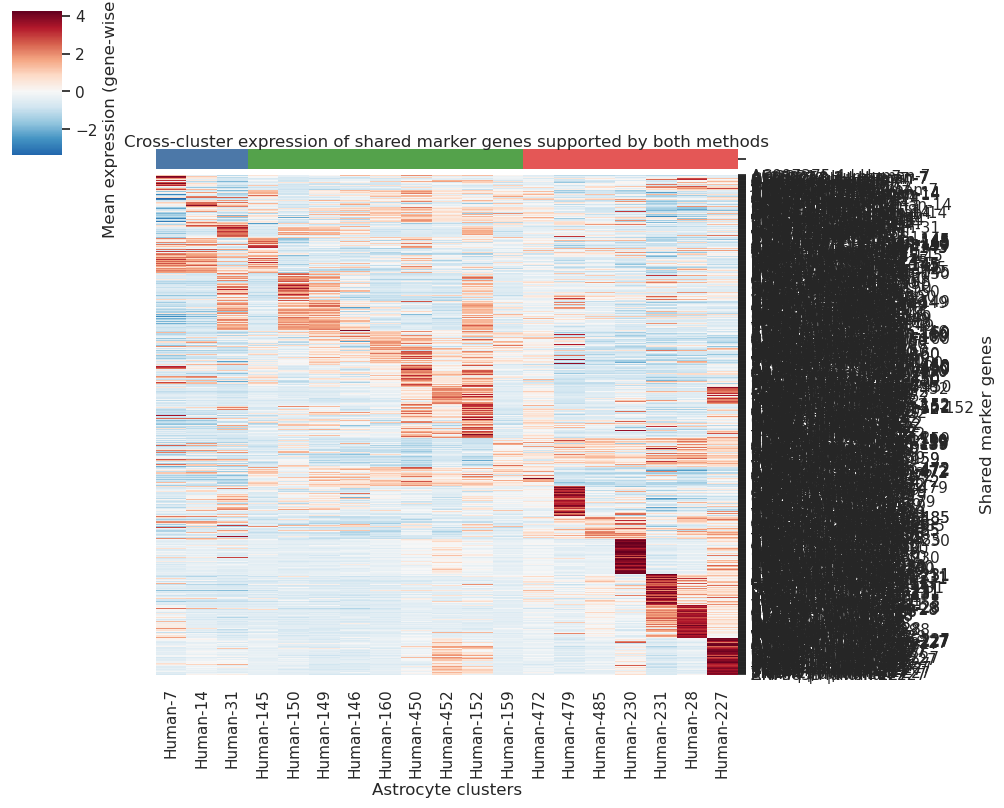

Saved heatmap to: /scratch/shared_marker_between_Methods_heatmap_cross_clusters.pdf


In [30]:
import seaborn as sns
from scipy.stats import spearmanr, zscore

TOP_N = 50
MIN_OVERLAP_FOR_CLUSTER = 10
OUTPUT_PDF = "/scratch/shared_marker_between_Methods_heatmap_cross_clusters.pdf"

cluster_order = [
    'Human-7', 'Human-14', 'Human-31',
    'Human-145', 'Human-150', 'Human-149', 'Human-146', 'Human-160', 'Human-450', 'Human-452', 'Human-152', 'Human-159',
    'Human-472', 'Human-479', 'Human-485', 'Human-230', 'Human-231', 'Human-28', 'Human-227',
    #'Human-232', 'Human-143'
]

h19.obs['Cluster'] = pd.Categorical(
    h19.obs['Cluster'],
    categories=cluster_order,
    ordered=True
)
adata = h19.copy()

# =========================================================
# Step 0. Standardize column names
# =========================================================
df_scanpy_all = df_all_clusters_filtered.copy()
df_deseq_all = df_all_deg.copy()

if "names" in df_scanpy_all.columns:
    df_scanpy_all = df_scanpy_all.rename(columns={"names": "gene"})
if "logfoldchanges" in df_scanpy_all.columns:
    df_scanpy_all = df_scanpy_all.rename(columns={"logfoldchanges": "logFC_scanpy"})

if "names" in df_deseq_all.columns and "gene" not in df_deseq_all.columns:
    df_deseq_all = df_deseq_all.rename(columns={"names": "gene"})
if "log2FoldChange" in df_deseq_all.columns:
    df_deseq_all = df_deseq_all.rename(columns={"log2FoldChange": "logFC_deseq"})

required_scanpy_cols = {"cluster", "gene", "logFC_scanpy"}
required_deseq_cols = {"cluster", "gene", "logFC_deseq"}

missing_scanpy = required_scanpy_cols - set(df_scanpy_all.columns)
missing_deseq = required_deseq_cols - set(df_deseq_all.columns)

if missing_scanpy:
    raise ValueError(f"df_all_clusters_filtered is missing columns: {missing_scanpy}")
if missing_deseq:
    raise ValueError(f"df_all_deg is missing columns: {missing_deseq}")

# =========================================================
# Step 1. Compute per-cluster overlap and Spearman correlation
# =========================================================
cluster_stats = []
shared_marker_dict = {}
shared_marker_rows = []

all_clusters = sorted(df_scanpy_all["cluster"].unique())

for cl in all_clusters:
    df_deseq = df_deseq_all[df_deseq_all["cluster"] == cl].copy()
    df_scanpy = df_scanpy_all[df_scanpy_all["cluster"] == cl].copy()

    if df_deseq.empty or df_scanpy.empty:
        continue

    df_merge = pd.merge(
        df_scanpy[["gene", "logFC_scanpy"]],
        df_deseq[["gene", "logFC_deseq"]],
        on="gene",
        how="inner"
    )

    n_overlap = df_merge.shape[0]

    if n_overlap >= MIN_OVERLAP_FOR_CLUSTER:
        r, _ = spearmanr(df_merge["logFC_scanpy"], df_merge["logFC_deseq"])
    else:
        r = np.nan

    cluster_stats.append({
        "cluster": cl,
        "n_overlap": n_overlap,
        "spearman_r": r
    })

    # Keep only genes supported by both methods and with positive direction
    df_merge = df_merge[
        (df_merge["logFC_scanpy"] > 0) &
        (df_merge["logFC_deseq"] > 0)
    ].copy()

    if df_merge.empty:
        continue

    # Rank genes using the average rank across both methods
    df_merge["rank_scanpy"] = df_merge["logFC_scanpy"].rank(ascending=False, method="average")
    df_merge["rank_deseq"] = df_merge["logFC_deseq"].rank(ascending=False, method="average")
    df_merge["rank_mean"] = (df_merge["rank_scanpy"] + df_merge["rank_deseq"]) / 2

    df_merge = df_merge.sort_values("rank_mean", ascending=True)

    top_genes = df_merge.head(TOP_N)["gene"].tolist()
    shared_marker_dict[cl] = top_genes

    tmp = df_merge.head(TOP_N).copy()
    tmp["cluster_marker_of"] = cl
    shared_marker_rows.append(tmp)

df_cluster_stats = pd.DataFrame(cluster_stats)

# Order clusters by Spearman correlation, then append clusters without valid correlation
df_cluster_stats_valid = df_cluster_stats.dropna(subset=["spearman_r"]).sort_values("spearman_r", ascending=False)
#clusters_sorted = df_cluster_stats_valid["cluster"].tolist()
#Use the predefined biological cluster order
clusters_sorted = [c for c in cluster_order if c in all_clusters]
missing_clusters = [c for c in all_clusters if c not in clusters_sorted]
clusters_sorted += missing_clusters


print("Number of clusters:", len(all_clusters))
print("Clusters with valid Spearman correlation:", df_cluster_stats_valid.shape[0])

# =========================================================
# Step 2. Build the union of shared marker genes across clusters
# =========================================================
if len(shared_marker_rows) == 0:
    raise ValueError("No shared marker genes were found across methods.")

df_shared_markers = pd.concat(shared_marker_rows, ignore_index=True)

shared_genes = []
for cl in clusters_sorted:
    if cl in shared_marker_dict:
        for g in shared_marker_dict[cl]:
            if g not in shared_genes:
                shared_genes.append(g)

# Keep only genes present in the AnnData object
shared_genes = [g for g in shared_genes if g in adata.var_names]

if len(shared_genes) == 0:
    raise ValueError("None of the shared marker genes are present in adata.var_names.")

print("Total shared marker genes kept for heatmap:", len(shared_genes))

# =========================================================
# Step 3. Compute average expression of shared genes in each cluster
# =========================================================
expr_mat = []
clusters_kept = []

for cl in clusters_sorted:
    cells = adata.obs["Cluster"] == cl
    if cells.sum() == 0:
        continue

    X = adata[cells, shared_genes].X

    if not isinstance(X, np.ndarray):
        X = X.toarray()

    mean_expr = X.mean(axis=0)
    expr_mat.append(mean_expr)
    clusters_kept.append(cl)

expr_mat = np.vstack(expr_mat)

df_expr = pd.DataFrame(
    expr_mat,
    index=clusters_kept,
    columns=shared_genes
).T

# Z-score each gene across clusters
df_expr_z = df_expr.apply(lambda x: zscore(x, nan_policy="omit"), axis=1)
df_expr_z = df_expr_z.fillna(0)

print("Expression matrix shape:", df_expr_z.shape)

# =========================================================
# Step 4. Order genes by the cluster they were selected from
# =========================================================
gene_to_cluster = {}
for cl, genes in shared_marker_dict.items():
    for g in genes:
        if g not in gene_to_cluster:
            gene_to_cluster[g] = cl

def cluster_rank_for_gene(gene):
    cl = gene_to_cluster.get(gene, None)
    if cl is None or cl not in clusters_kept:
        return len(clusters_kept)
    return clusters_kept.index(cl)

gene_order = sorted(
    df_expr_z.index,
    key=lambda g: (cluster_rank_for_gene(g), g)
)

df_expr_z = df_expr_z.loc[gene_order]

# Optional: label each gene with its source cluster
gene_labels = []
for g in df_expr_z.index:
    cl = gene_to_cluster.get(g, "NA")
    gene_labels.append(f"{g} | {cl}")
df_expr_z.index = gene_labels

# =========================================================
# Step 5. Build subgroup annotation bar
# =========================================================
subgroup_col = "subGroup"

if subgroup_col not in adata.obs.columns:
    raise ValueError(f"adata.obs does not contain '{subgroup_col}'.")

cluster_to_subgroup = (
    adata.obs[["Cluster", subgroup_col]]
    .drop_duplicates()
    .set_index("Cluster")[subgroup_col]
    .to_dict()
)

subgroup_palette = {
    "GM STR": "#4C78A8",
    "GM exSTR": "#54A24B",
    "WM": "#E45756",
    "mixed": "#B279A2"
}

col_colors = pd.Series(clusters_kept).map(
    lambda x: subgroup_palette.get(cluster_to_subgroup.get(x, "mixed"), "#BBBBBB")
)
col_colors.index = clusters_kept

# =========================================================
# Step 6. Plot heatmap
# =========================================================
sns.set(style="white")

#fig_height = max(8, len(df_expr_z.index) * 0.18)
fig_height = 8

g = sns.clustermap(
    df_expr_z,
    row_cluster=False,
    col_cluster=False,
    col_colors=col_colors,
    cmap="RdBu_r",
    center=0,
    xticklabels=True,
    yticklabels=True,
    figsize=(10, fig_height),
    cbar_kws={"label": "Mean expression (gene-wise z-score)"},
    linewidths=0
)

g.ax_heatmap.set_xlabel("Astrocyte clusters")
g.ax_heatmap.set_ylabel("Shared marker genes")
g.ax_heatmap.set_title("Cross-cluster expression of shared marker genes supported by both methods", pad=20)

# Rotate x tick labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

# Save output
g.savefig(OUTPUT_PDF, dpi=400, bbox_inches="tight")
plt.show()

print(f"Saved heatmap to: {OUTPUT_PDF}")